### Phase 2: Feature Engineering

In [1]:
# =====================================================
# 🧠 PHASE 2 — FEATURE ENGINEERING
# =====================================================

import os
import logging
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
# -----------------------------------------------------
# Step 1: Setup paths & logging
# -----------------------------------------------------

PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FEATURE_DIR = PROJECT_ROOT / "data" / "features"
CONCALL_DIR = PROJECT_ROOT / "data" / "concall"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.WARNING)

DATASET_DIR = DATA_DIR / "datasets"
DATASET_DIR.mkdir(parents=True, exist_ok=True)

print(f"📈 Found {len(list(DATA_DIR.glob('*.csv')))} raw files.")

📈 Found 100 raw files.


<IPython.core.display.Javascript object>

In [3]:
print("Total CSV files:", len(os.listdir(DATA_DIR)))

for f in os.listdir(DATA_DIR):
    if f.endswith(".csv"):
        print(f)

Total CSV files: 101
ABB.csv
ADANIENSOL.csv
ADANIENT.csv
ADANIGREEN.csv
ADANIPORTS.csv
ADANIPOWER.csv
AMBUJACEM.csv
APOLLOHOSP.csv
ASIANPAINT.csv
AXISBANK.csv
BAJAJ-AUTO.csv
BAJAJFINSV.csv
BAJAJHFL.csv
BAJAJHLDNG.csv
BAJFINANCE.csv
BANKBARODA.csv
BEL.csv
BHARTIARTL.csv
BOSCHLTD.csv
BPCL.csv
BRITANNIA.csv
CANBK.csv
CGPOWER.csv
CHOLAFIN.csv
CIPLA.csv
COALINDIA.csv
DIVISLAB.csv
DLF.csv
DMART.csv
DRREDDY.csv
EICHERMOT.csv
ENRIN.csv
ETERNAL.csv
GAIL.csv
GODREJCP.csv
GRASIM.csv
HAL.csv
HAVELLS.csv
HCLTECH.csv
HDFCBANK.csv
HDFCLIFE.csv
HINDALCO.csv
HINDUNILVR.csv
HINDZINC.csv
HYUNDAI.csv
ICICIBANK.csv
ICICIGI.csv
INDHOTEL.csv
INDIGO.csv
INFY.csv
IOC.csv
IRFC.csv
ITC.csv
JINDALSTEL.csv
JIOFIN.csv
JSWENERGY.csv
JSWSTEEL.csv
KOTAKBANK.csv
LICI.csv
LODHA.csv
LT.csv
LTM.csv
M&M.csv
MARUTI.csv
MAXHEALTH.csv
MAZDOCK.csv
MOTHERSON.csv
NAUKRI.csv
NESTLEIND.csv
NTPC.csv
ONGC.csv
PFC.csv
PIDILITIND.csv
PNB.csv
POWERGRID.csv
RECLTD.csv
RELIANCE.csv
SBILIFE.csv
SBIN.csv
SHREECEM.csv
SHRIRAMFIN.csv
SIEMENS

<IPython.core.display.Javascript object>

In [4]:
# -----------------------------------------------------
# Step 2: Technical Indicator Functions
# -----------------------------------------------------

def compute_technical_features(df):

    df = df.sort_values("Date").copy()
    
    # Returns
    df["ret_1d"] = df["Close"].pct_change()
    df["ret_5d"] = df["Close"].pct_change(5)
    df["ret_21d"] = df["Close"].pct_change(21)

    # Momentum
    df["momentum_1m"] = df["Close"].pct_change(21)
    df["momentum_3m"] = df["Close"].pct_change(63)
    df["momentum_6m"] = df["Close"].pct_change(126)

    # Volatility
    df["vol_30d"] = df["ret_1d"].rolling(30).std().shift(1)
    df["vol_90d"] = df["ret_1d"].rolling(90).std().shift(1)

    # RSI
    delta = df["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss

    df["rsi_14"] = (100 - (100 / (1 + rs))).shift(1)

    # MACD
    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()

    df["macd"] = (ema12 - ema26).shift(1)
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean().shift(1)
    df["macd_hist"] = (df["macd"] - df["macd_signal"]).shift(1)

    # EMA Cross
    df["ema_fast"] = df["Close"].ewm(span=20, adjust=False).mean()
    df["ema_slow"] = df["Close"].ewm(span=50, adjust=False).mean()

    df["ema_cross"] = (df["ema_fast"] > df["ema_slow"]).astype(int).shift(1)

    # Volume Features
    df["volume_change"] = df["Volume"].pct_change().shift(1)

    vol_mean = df["Volume"].rolling(30).mean()
    vol_std = df["Volume"].rolling(30).std()

    df["volume_zscore"] = ((df["Volume"] - vol_mean) / vol_std).shift(1)

    df["volume_momentum"] = (df["Volume"] / df["Volume"].rolling(21).mean()).shift(1)

    # Price Range Position
    rolling_high = df["High"].rolling(20).max()
    rolling_low = df["Low"].rolling(20).min()

    df["range_position"] = ((df["Close"] - rolling_low) /
                           (rolling_high - rolling_low)).shift(1)

    # Distribution Shape
    df["ret_skew_10"] = df["ret_1d"].rolling(10).skew().shift(1)
    df["ret_kurt_10"] = df["ret_1d"].rolling(10).kurt().shift(1)
    df["ret_skew_30"] = df["ret_1d"].rolling(30).skew().shift(1)
    df["ret_kurt_30"] = df["ret_1d"].rolling(30).kurt().shift(1)

    return df


<IPython.core.display.Javascript object>

### Engineered Feature Descriptions

#### Trading Window Assumptions
- Quant finance commonly assumes **21 trading days per month**.
- Standard rolling windows used:
  - **21 days** → ~1 month
  - **63 days** → ~3 months
  - **126 days** → ~6 months

#### Leakage Prevention
- `shift(1)` is applied across relevant features to prevent **look-ahead bias**.
- Without shifting, the present day value could leak into the feature calculation.

#### Volatility & Portfolio Metrics
- Volatility is included as a feature.
- **Sharpe Ratio** and **Sortino Ratio** are portfolio-level metrics, so they will be calculated later using volatility in **Phase 4 – Portfolio Construction**.

#### Momentum Indicators

**RSI (Relative Strength Index)**
- Default RSI uses the **last 14 trading days**.
- Two intermediate features are created:
  - **gain**
  - **loss**
- Example transformation:

  Returns: `-1, -3, 5, 2`  
  Loss column: `-1, -3, 0, 0`  
  Gain column: `0, 0, 5, 2`

- RSI helps identify **overbought and oversold conditions** in stocks.

**MACD (Moving Average Convergence Divergence)**
- Formula: **MACD = EMA12 − EMA26** (short-term EMA minus long-term EMA).
- Captures **monthly trend acceleration**.
- The **12 and 26 trading day EMAs** follow the standard specification introduced by Gerald Appel.
- Interpretation:
  - **MACD > 0** → bullish momentum
  - **MACD < 0** → bearish momentum

#### Volume-Based Features
- **volume_z**
  - Measures unusual trading activity.
  - Example:  
    - `volume_z = 3` → unusually high trading activity  
    - `volume_z = 0` → normal activity

- **volume_momentum**
  - Measures recent **liquidity surge**.
  - High values indicate **increased market attention**.

#### Price Range Position
- **Range position**
  - Indicates where the price lies within its recent range.
  - `0` → near support  
  - `1` → near resistance

#### Distribution Shape of Returns

- **Rolling Skewness**
  - Measures asymmetry of returns.
  - Positive skew → small losses with occasional large gains.
  - Negative skew → frequent small gains with risk of sharp crashes.

- **Rolling Kurtosis**
  - Measures likelihood of **extreme returns**.
  - Example situations:
    - calm trading periods followed by sudden large moves due to earnings surprises
    - panic-driven market reactions such as geopolitical events (e.g., Iran–Israel conflict).

In [5]:
# -----------------------------------------------------
# Step 2.5: Enhanced Concall Tone + Guidance Features
# -----------------------------------------------------

# --- Financial Tone Dictionaries (Unchanged) ---

POSITIVE_WORDS = set(
    [
        "growth",
        "strong",
        "improve",
        "improved",
        "improving",
        "improvement",
        "increase",
        "profit",
        "profits",
        "profitable",
        "expansion",
        "expand",
        "expanding",
        "robust",
        "positive",
        "optimistic",
        "confidence",
        "confident",
        "opportunity",
        "opportunities",
        "momentum",
        "resilient",
        "outperform",
        "record",
        "efficient",
        "efficiency",
        "benefit",
        "benefitted",
        "better",
        "gain",
        "healthy",
    ]
)

NEGATIVE_WORDS = set(
    [
        "decline",
        "declining",
        "declined",
        "loss",
        "losses",
        "weak",
        "weakness",
        "risk",
        "risks",
        "slowdown",
        "pressure",
        "pressures",
        "uncertain",
        "uncertainty",
        "challenge",
        "challenges",
        "volatile",
        "volatility",
        "concern",
        "concerns",
        "drop",
        "decrease",
        "decreasing",
        "headwind",
        "headwinds",
        "underperform",
        "challenging",
        "negative",
        "contraction",
        "impairment",
        "shortages",
    ]
)

GUIDANCE_WORDS = set(
    [
        "guidance",
        "outlook",
        "forecast",
        "expect",
        "expects",
        "expected",
        "projection",
        "projections",
        "estimate",
        "estimates",
        "target",
        "targets",
        "aim",
        "anticipate",
        "anticipates",
    ]
)


def compute_concall_tone(text):
    """Compute tone and guidance features from transcript text."""

    if pd.isna(text):
        return 0, 0, 0, 0, 0

    words = str(text).lower().split()
    total_words = len(words)

    if total_words == 0:
        return 0, 0, 0, 0, 0

    pos_count = sum(1 for w in words if w in POSITIVE_WORDS)
    neg_count = sum(1 for w in words if w in NEGATIVE_WORDS)
    guidance_flag = int(any(w in GUIDANCE_WORDS for w in words))

    pos_ratio = pos_count / total_words
    neg_ratio = neg_count / total_words
    net_tone = pos_ratio - neg_ratio
    tone_intensity = pos_ratio + neg_ratio

    return pos_ratio, neg_ratio, net_tone, tone_intensity, guidance_flag


def load_and_aggregate_concall(symbol):
    concall_file = CONCALL_DIR / f"{symbol}_concall.csv"

    if not concall_file.exists():
        return None

    df = pd.read_csv(concall_file)

    if df.empty:
        return None

    # ✅ Standardize column name to "Date"
    df["Date"] = pd.to_datetime(df["date"], errors="coerce")
    df.dropna(subset=["Date"], inplace=True)

    if "text" not in df.columns:
        return None

    # --- Compute tone metrics ---
    tone_features = df["text"].apply(compute_concall_tone)

    df[
        ["pos_ratio", "neg_ratio", "net_tone", "tone_intensity", "guidance_flag"]
    ] = pd.DataFrame(tone_features.tolist(), index=df.index)

    df = df.sort_values("Date")

    # 🔴 CRITICAL: Shift BEFORE rolling
    # Calculate the difference between the tone of rolling mean of previous 4 concalls and current concall
    df["tone_rolling_mean"] = df["net_tone"].shift(1).rolling(4, min_periods=1).mean()

    df["tone_surprise"] = df["net_tone"] - df["tone_rolling_mean"]

    # --- Aggregate Daily ---
    concall_agg = (
        df.groupby("Date")
        .agg(
            concall_count=("text", "count"),
            concall_pos_ratio=("pos_ratio", "mean"),
            concall_neg_ratio=("neg_ratio", "mean"),
            concall_net_tone=("net_tone", "mean"),
            concall_tone_intensity=("tone_intensity", "mean"),
            concall_tone_surprise=("tone_surprise", "mean"),
            concall_guidance_flag=("guidance_flag", "max"),
        )
        .reset_index()
    )

    return concall_agg

<IPython.core.display.Javascript object>

In [6]:
# -----------------------------------------------------
# Concall Feature Column List
# -----------------------------------------------------

concall_cols = [
    "concall_count",
    "concall_pos_ratio",
    "concall_neg_ratio",
    "concall_net_tone",
    "concall_tone_intensity",
    "concall_tone_surprise",
    "concall_guidance_flag",
]

<IPython.core.display.Javascript object>

In [7]:
# -----------------------------------------------------
# Clean feature directory before run
# -----------------------------------------------------

for f in FEATURE_DIR.glob("*.csv"):
    f.unlink()

print("🧹 Cleared old feature files")

🧹 Cleared old feature files


<IPython.core.display.Javascript object>

In [8]:
all_ticker_dfs = []

<IPython.core.display.Javascript object>

In [9]:
# -----------------------------------------------------
# Step 3: Process Each Ticker
# -----------------------------------------------------

all_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
print(f"📈 Processing {len(all_files)} tickers...")

all_ticker_dfs = []

for file in tqdm(all_files):
    try:
        file_path = DATA_DIR / file
        symbol = file.replace(".csv", "")

        df = pd.read_csv(file_path)

        # --- Clean column names ---
        df.columns = [c.strip().lower() for c in df.columns]

        col_map = {
            "date": "Date",
            "openprice": "Open",
            "open": "Open",
            "highprice": "High",
            "high": "High",
            "lowprice": "Low",
            "low": "Low",
            "closeprice": "Close",
            "close": "Close",
            "totaltradedquantity": "Volume",
            "volume": "Volume",
        }

        df.rename(columns=col_map, inplace=True)

        # --- Validate Required Columns ---
        required_cols = ["Date", "Open", "High", "Low", "Close", "Volume"]
        for c in required_cols:
            if c not in df.columns:
                raise ValueError(f"{file} missing column: {c}")

        # --- Parse Date ---
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df.dropna(subset=["Date"], inplace=True)

        # --- Numeric Conversion ---
        for col in ["Open", "High", "Low", "Close", "Volume"]:
            df[col] = (
                df[col].astype(str).str.replace(",", "", regex=False).astype(float)
            )

        df.sort_values("Date", inplace=True)

        # =================================================
        # 🔹 Merge Concall Features
        # =================================================

        concall_df = load_and_aggregate_concall(symbol)

        if concall_df is not None:

            df = df.merge(concall_df, on="Date", how="left")

            # Forward fill concall signal until next call
            df[concall_cols] = df[concall_cols].ffill().fillna(0)

        else:
            # If no concall data exists
            df[concall_cols] = 0

        # =================================================
        # 🔹 Technical Features
        # =================================================

        df_feat = compute_technical_features(df)

        # --- Drop early NA rows (indicator warmup) ---
        min_required_cols = ["momentum_6m", "vol_90d", "rsi_14", "macd_hist"]
        df_feat.dropna(subset=min_required_cols, inplace=True)

        # --- Remove remaining NaNs ---
        # --- Remove remaining NaNs only from essential feature columns ---
        rows_before = len(df_feat)
        essential_cols = [
            "ret_1d",
            "ret_5d",
            "ret_21d",
            "momentum_1m",
            "momentum_3m",
            "momentum_6m",
            "vol_30d",
            "vol_90d",
            "rsi_14",
            "macd_hist",
        ]

        df_feat = df_feat.dropna(subset=essential_cols)
        rows_after = len(df_feat)

        print(
            f"{symbol} | before: {rows_before} | after: {rows_after} | removed: {rows_before - rows_after}"
        )

        # -------------------------------------------------
        # Add ticker column and store dataframe
        # -------------------------------------------------

        df_feat["ticker"] = symbol
        all_ticker_dfs.append(df_feat)

        # =================================================
        # 🔹 Save Features (per ticker)
        # =================================================

        df_feat.to_csv(FEATURE_DIR / file, index=False)

    except Exception as e:
        logging.warning(f"❌ Failed for {file}: {e}")
        continue

print("✅ Feature engineering completed for all tickers!")

# =================================================
# 🔹 Combine all tickers into one dataframe
# =================================================

combined_df = pd.concat(all_ticker_dfs, ignore_index=True)

print("Combined dataset shape:", combined_df.shape)

combined_df.to_csv(DATASET_DIR / "combined_features.csv", index=False)

print("✅ Combined dataset saved!")

📈 Processing 100 tickers...


  1%|          | 1/100 [00:00<00:17,  5.70it/s]

ABB | before: 1413 | after: 1413 | removed: 0


  2%|▏         | 2/100 [00:00<00:14,  6.69it/s]

ADANIENSOL | before: 1248 | after: 1248 | removed: 0


...

100%|██████████| 100/100 [00:16<00:00,  6.53it/s]

WIPRO | before: 1416 | after: 1416 | removed: 0
ZYDUSLIFE | before: 1416 | after: 1416 | removed: 0


100%|██████████| 100/100 [00:16<00:00,  6.25it/s]


✅ Feature engineering completed for all tickers!
Combined dataset shape: (134158, 46)
✅ Combined dataset saved!


<IPython.core.display.Javascript object>

In [10]:
# -----------------------------------------------------
# Step 4: Sanity Check Summary (UPDATED)
# -----------------------------------------------------

feature_files = list(FEATURE_DIR.glob("*.csv"))

if len(feature_files) == 0:
    print("⚠️ No feature files found in FEATURE_DIR.")
else:
    sample_file = feature_files[0]
    df_sample = pd.read_csv(sample_file)

    print(f"\n🧩 Sample engineered dataset preview: {sample_file.name}")
    print(f"Shape: {df_sample.shape}")
    print(f"Columns: {len(df_sample.columns)}")

    preview_cols = [
        # Price
        "Date",
        "Close",
        # Technical
        "momentum_1m",
        "vol_30d",
        "rsi_14",
        "macd_hist",
        "ema_cross",
        # News
        "sent_3d",
        "news_intensity",
        # Concall (New Tone Features)
        "concall_pos_ratio",
        "concall_neg_ratio",
        "concall_net_tone",
        "concall_tone_surprise",
        "concall_guidance_flag",
    ]

    preview_cols = [c for c in preview_cols if c in df_sample.columns]

    print("\n📊 Preview:")
    print(df_sample.head(10)[preview_cols])

    print("\n🔎 Missing values:")
    print(df_sample[preview_cols].isna().sum())

    print("\n📈 Basic Stats (Tone Features):")
    tone_cols = [
        "concall_pos_ratio",
        "concall_neg_ratio",
        "concall_net_tone",
        "concall_tone_surprise",
    ]
    tone_cols = [c for c in tone_cols if c in df_sample.columns]


🧩 Sample engineered dataset preview: ABB.csv
Shape: (1413, 46)
Columns: 46

📊 Preview:
         Date   Close  momentum_1m   vol_30d     rsi_14  macd_hist  ema_cross  \
0  2020-07-09  928.50     0.118203  0.026273  83.486043  16.543673        1.0   
1  2020-07-10  916.95     0.131967  0.026683  75.632490  11.768701        1.0   
2  2020-07-13  914.90     0.133143  0.026940  69.455298   6.549202        1.0   
3  2020-07-14  908.15     0.126597  0.019898  65.237249   1.676724        1.0   
4  2020-07-15  905.80     0.139443  0.020002  60.560797  -1.968814        1.0   
5  2020-07-16  905.85     0.154464  0.019942  57.008310  -5.024664        1.0   
6  2020-07-17  912.15     0.158286  0.019935  47.102931  -7.188268        1.0   
7  2020-07-20  898.95     0.105720  0.017786  46.482759  -8.471374        1.0   
8  2020-07-21  906.85     0.089571  0.018022  34.863702  -8.617453        1.0   
9  2020-07-22  925.65     0.082822  0.017146  32.314573  -9.579124        1.0   

   concall_pos_ratio

<IPython.core.display.Javascript object>

In [11]:
sample_file

WindowsPath('C:/Users/jayan/Study Materials/ml_alpha_portfolio/ml-alpha-portfolio-model/data/features/ABB.csv')

<IPython.core.display.Javascript object>

In [12]:
df_sample.head(10)

,symbol,series,Date,prevclose,Open,High,Low,lastprice,Close,averageprice,...,ema_cross,volume_change,volume_zscore,volume_momentum,range_position,ret_skew_10,ret_kurt_10,ret_skew_30,ret_kurt_30,ticker
0,ABB,EQ,2020-07-09,944.65,947.0,955.00,926.05,928.50,928.50,935.78,...,1.0,-0.348057,-0.423497,0.661031,0.694726,-0.470712,0.561822,1.586652,4.910106,ABB
1,ABB,EQ,2020-07-10,928.50,930.0,936.75,914.90,915.15,916.95,922.61,...,1.0,-0.358806,-0.684358,0.422289,0.626582,-0.076611,-0.568611,1.567801,4.639617,ABB
2,ABB,EQ,2020-07-13,916.95,922.0,925.35,910.00,913.00,914.90,915.72,...,1.0,-0.125050,-0.727788,0.370324,0.576059,-0.292588,-1.826528,1.580516,4.514614,ABB
3,ABB,EQ,2020-07-14,914.90,913.0,915.00,901.05,910.50,908.15,909.57,...,1.0,-0.298542,-0.802432,0.261442,0.567373,-0.067318,-1.759699,0.301155,-0.253586,ABB
4,ABB,EQ,2020-07-15,908.15,916.0,933.00,900.90,906.10,905.80,915.57,...,1.0,-0.296824,-0.847989,0.184227,0.538771,0.170259,-1.538606,0.352418,-0.284297,ABB
5,ABB,EQ,2020-07-16,905.80,909.9,919.00,894.00,909.95,905.85,906.95,...,1.0,1.548927,-0.496675,0.467343,0.521618,0.361910,-0.797694,0.435391,-0.201512,ABB
6,ABB,EQ,2020-07-17,905.85,914.0,923.25,907.00,914.50,912.15,914.18,...,1.0,0.050908,-0.444540,0.490755,0.514629,0.496589,0.069088,0.430208,-0.201186,ABB
7,ABB,EQ,2020-07-20,912.15,913.5,932.70,894.00,894.95,898.95,908.38,...,1.0,-0.297600,-0.579727,0.345025,0.462170,-0.174724,-1.296382,0.145850,-0.630770,ABB
8,ABB,EQ,2020-07-21,898.95,903.0,913.95,901.15,907.00,906.85,907.17,...,1.0,1.828961,0.152304,1.180805,0.361374,0.243239,-0.964872,0.207245,-0.722725,ABB
9,ABB,EQ,2020-07-22,906.85,910.0,930.00,902.00,926.25,925.65,918.94,...,1.0,-0.558590,-0.467639,0.526237,0.319011,0.233951,-1.289198,0.206795,-0.658554,ABB


<IPython.core.display.Javascript object>

In [13]:
# -----------------------------------------------------
# Step 5: Data Availability Check Across All Stocks
# -----------------------------------------------------

feature_files = list(FEATURE_DIR.glob("*.csv"))

availability_summary = []

for file in feature_files:
    df = pd.read_csv(file)

    row_count = len(df)

    # Ensure Date exists and is parsed
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        start_date = df['Date'].min()
        end_date = df['Date'].max()
        date_span_years = (end_date - start_date).days / 365
    else:
        start_date = None
        end_date = None
        date_span_years = None

    availability_summary.append({
        "symbol": file.stem,
        "rows": row_count,
        "start_date": start_date,
        "end_date": end_date,
        "years_span": round(date_span_years, 2) if date_span_years else None
    })

availability_df = pd.DataFrame(availability_summary)


<IPython.core.display.Javascript object>

In [14]:
# -----------------------------------------------------
# Summary Stats
# -----------------------------------------------------

print("\n📊 Data Availability Summary")
print("-" * 40)
print(availability_df['rows'].describe())

print("\n📅 Years Span Summary")
print("-" * 40)
print(availability_df['years_span'].describe())

# -----------------------------------------------------
# Stocks Below 1000 Rows
# -----------------------------------------------------

low_data = availability_df[availability_df['rows'] < 1000]

print(f"\n⚠️ Stocks with < 1000 rows: {len(low_data)}")
print(low_data.sort_values("rows").head(10))



📊 Data Availability Summary
----------------------------------------
count     100.000000
mean     1341.580000
std       242.821262
min        48.000000
25%      1416.000000
50%      1416.000000
75%      1416.000000
max      1416.000000
Name: rows, dtype: float64

📅 Years Span Summary
----------------------------------------
count    100.000000
mean       5.422200
std        0.974278
min        0.180000
25%        5.690000
50%        5.690000
75%        5.690000
max        5.690000
Name: years_span, dtype: float64

⚠️ Stocks with < 1000 rows: 5
      symbol  rows start_date   end_date  years_span
31     ENRIN    48 2026-01-05 2026-03-13        0.18
44   HYUNDAI   221 2025-04-28 2026-03-13        0.87
12  BAJAJHFL   246 2025-03-18 2026-03-13        0.99
54    JIOFIN   502 2024-03-05 2026-03-13        2.02
58      LICI   826 2022-11-17 2026-03-13        3.32


<IPython.core.display.Javascript object>

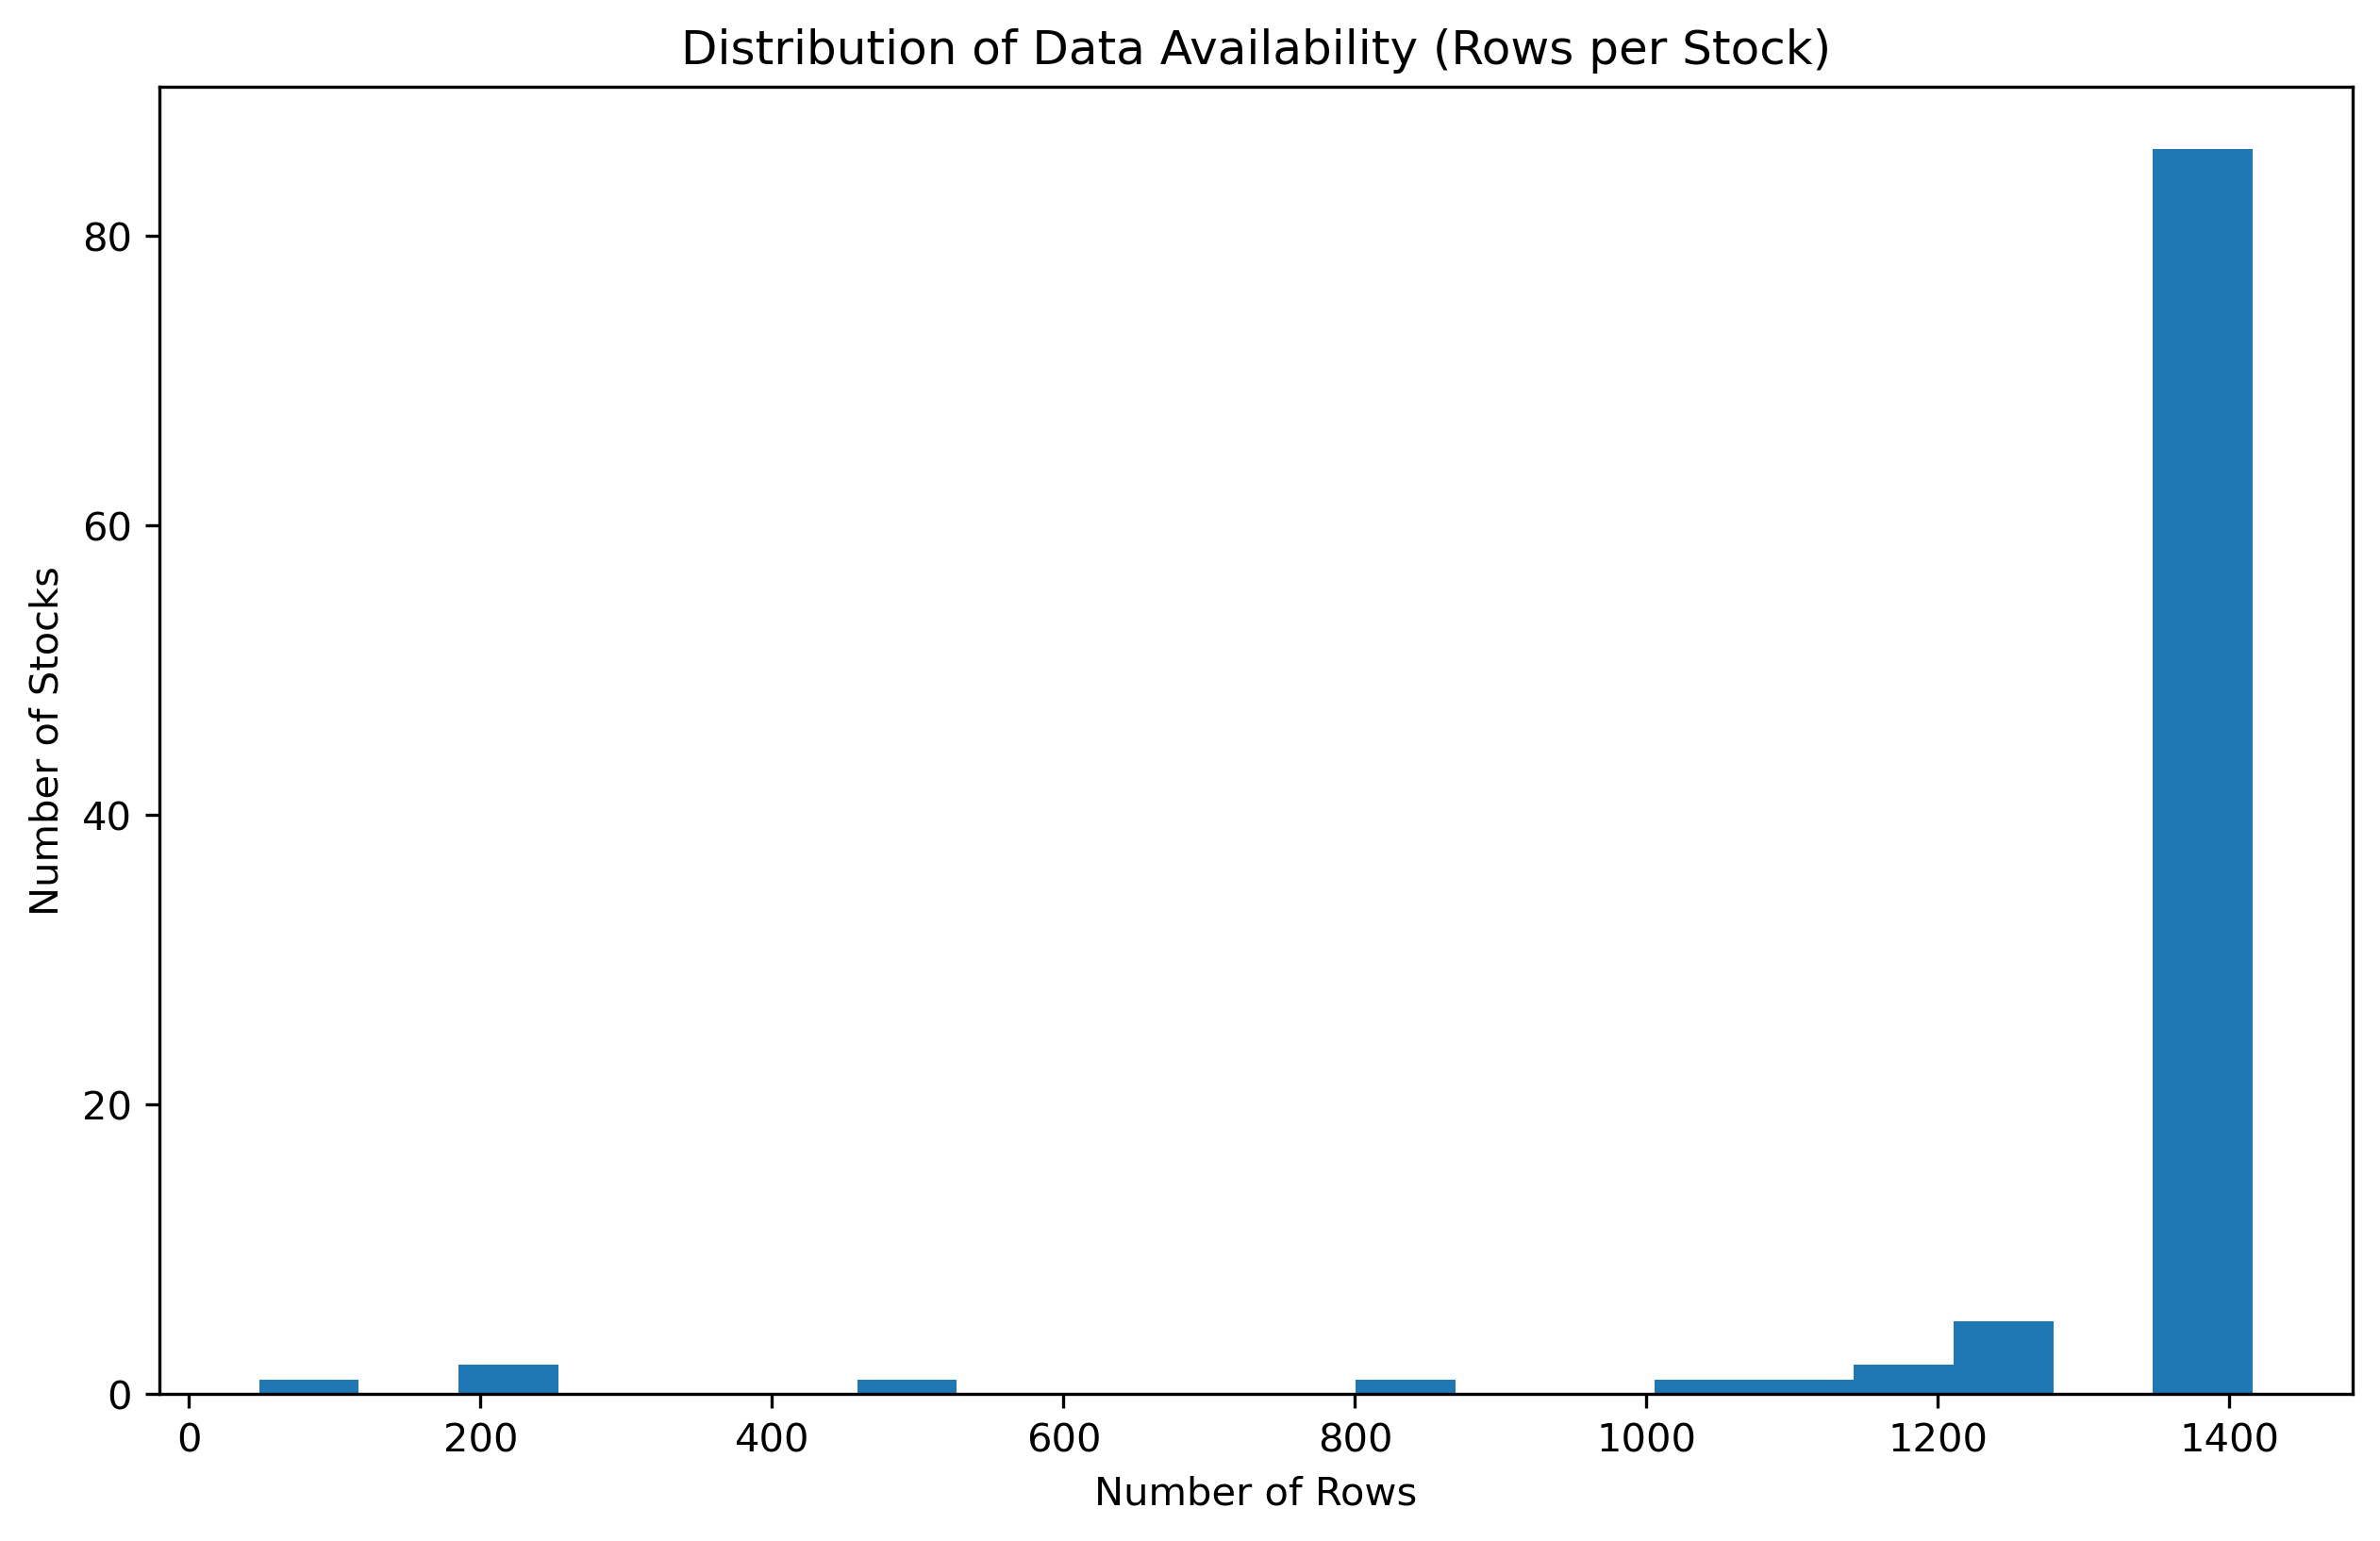

<IPython.core.display.Javascript object>

In [15]:
# -----------------------------------------------------
# Optional: Histogram of Row Distribution
# -----------------------------------------------------
plt.figure(figsize=(10, 6), dpi=300)
plt.hist(availability_df["rows"], bins=20)
plt.title("Distribution of Data Availability (Rows per Stock)")
plt.xlabel("Number of Rows")
plt.ylabel("Number of Stocks")
plt.show()

In [16]:
# -----------------------------------------------------
# Step 6: Filter Stocks With Minimum 1000 Rows
# -----------------------------------------------------

MIN_DAYS = 1000

feature_files = list(FEATURE_DIR.glob("*.csv"))

kept = []
removed = []

for file in feature_files:
    df = pd.read_csv(file)

    if len(df) >= MIN_DAYS:
        kept.append(file.stem)
    else:
        removed.append(file.stem)
        file.unlink()  # delete file

print("\n🗑 Removed Stocks (< 1000 rows):", len(removed))
print("Sample removed:", removed[:10])

print("\n✅ Stocks Remaining:", len(kept))


🗑 Removed Stocks (< 1000 rows): 5
Sample removed: ['BAJAJHFL', 'ENRIN', 'HYUNDAI', 'JIOFIN', 'LICI']

✅ Stocks Remaining: 95


<IPython.core.display.Javascript object>

In [17]:
# -----------------------------------------------------
# Final Dataset Verification
# -----------------------------------------------------

remaining_files = list(FEATURE_DIR.glob("*.csv"))

row_counts = []

for file in remaining_files:
    df = pd.read_csv(file)
    row_counts.append(len(df))

print("\n📊 Remaining Dataset Stats")
print("Stocks:", len(remaining_files))
print("Min rows:", min(row_counts))
print("Median rows:", np.median(row_counts))
print("Max rows:", max(row_counts))


📊 Remaining Dataset Stats
Stocks: 95
Min rows: 1027
Median rows: 1416.0
Max rows: 1416


<IPython.core.display.Javascript object>

In [18]:
print(
    "Total rows across all stocks:",
    sum(len(pd.read_csv(f)) for f in FEATURE_DIR.glob("*.csv")),
)

Total rows across all stocks: 132315


<IPython.core.display.Javascript object>

### 132315 represent sufficient number of rows to start the modelling!

In [ ]:
# from pathlib import Path
# import pandas as pd

feature_files = list(FEATURE_DIR.glob("*.csv"))

summary = []

for f in feature_files:

    df = pd.read_csv(f)

    ticker = f.stem.replace("_features", "")

    summary.append({"ticker": ticker, "rows": len(df)})

summary_df = pd.DataFrame(summary)

print("Total rows:", summary_df["rows"].sum())
print("Total tickers:", len(summary_df))

summary_df.to_csv("phase2_metadata.csv", index=False)

In [ ]:
combined_df.isnull().sum()

In [ ]:
# -----------------------------------------------------------------------------
# Step 7: Visualization of price and parameters variations across the timeframe
# -----------------------------------------------------------------------------

feature_files = list(FEATURE_DIR.glob("*.csv"))
tickers = sorted([f.stem for f in feature_files])

print("Available Tickers:\n")

for t in tickers:
    print(t)

### Available Features for Plotting

These are the engineered features that can be visualized using the `plot_feature()` function.

---

#### Price & Volume

**Open**  : Opening price of the stock for the trading day.

**High**  : Highest price reached during the trading session.

**Low**  : Lowest price reached during the trading session.

**Close**  : Closing price of the stock for the day.

**Volume**  : Total traded quantity of the stock for that day.

---

#### Momentum Features

**momentum_1m**  : Price momentum over the past **1 month (~21 trading days)**.

**momentum_3m**  : Price momentum over the past **3 months (~63 trading days)**.

**momentum_6m**  : Price momentum over the past **6 months (~126 trading days)**.

Momentum features capture **trend strength** and are commonly used in **quantitative alpha strategies**.

---

#### Volatility Feature

**vol_90d**  : Rolling **90-day historical volatility** of returns.

This measures how **unstable the stock price has been over the past three months**.

---

#### Technical Indicators

**rsi_14**  : Relative Strength Index calculated over **14 days**.  
Used to identify **overbought (>70)** or **oversold (<30)** conditions.

**macd_hist**  : MACD Histogram derived from the **difference between MACD and its signal line**.  
Helps detect **trend acceleration and reversals**.

---

#### Concall-Based Signals

These features are derived from **earnings call transcripts**.

**concall_sentiment_score**  : Aggregated sentiment score derived from **management commentary during earnings calls**.

**concall_keyword_intensity**  : Intensity of financial keywords related to **growth, margin expansion, or risks**.

These signals are **forward-filled until the next earnings call** to capture the impact of **management guidance**.

In [ ]:
import pandas as pd
import plotly.graph_objects as go


def plot_feature(ticker, feature, start_date=None, end_date=None, years=None):

    file_path = FEATURE_DIR / f"{ticker}.csv"

    # Load dataset
    df = pd.read_csv(file_path)

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")

    # If years argument is used
    if years is not None:
        end_date = df["Date"].max()
        start_date = end_date - pd.DateOffset(years=years)

    # Apply filters
    if start_date:
        df = df[df["Date"] >= pd.to_datetime(start_date)]

    if end_date:
        df = df[df["Date"] <= pd.to_datetime(end_date)]

    # Validate feature
    if feature not in df.columns:
        raise ValueError(f"{feature} not found in dataset")

    # Plot using Plotly
    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df[feature],
            mode="lines",
            line=dict(color="black", width=1.5),
            name=feature,
        )
    )

    fig.update_layout(
        title=f"{ticker} - {feature}",
        template="plotly_white",
        hovermode="x unified",
        width=1100,
        height=450,
        margin=dict(l=80, r=80, t=60, b=60),
        xaxis=dict(title="Date", showline=True, linecolor="black", mirror=True),
        yaxis=dict(title=feature, showline=True, linecolor="black", mirror=True),
    )

    fig.show()

In [ ]:
plot_feature("ADANIPORTS", "rsi_14", years=2)

In [ ]:
plot_feature(
    ticker="TCS", feature="vol_90d", start_date="2022-01-01", end_date="2024-01-13"
)